<a href="https://colab.research.google.com/github/isadorapandas/data-science-teste-hipoteses/blob/main/Testando_hipoteses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# carregando bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# idade de aponsentadoria
dados_idade_aposentadoria = pd.read_csv("https://raw.githubusercontent.com/isadorapandas/data-science-teste-hipoteses/refs/heads/main/dados_idade_aposentadoria.csv")

# Tempo de Vida de uma Lâmpada
dados_vida_lampada = pd.read_csv("https://raw.githubusercontent.com/isadorapandas/data-science-teste-hipoteses/refs/heads/main/dados_vida_lampada.csv")

# Altura dos funcionarios
dados_alturas = pd.read_csv("https://raw.githubusercontent.com/isadorapandas/data-science-teste-hipoteses/refs/heads/main/dados_alturas.csv")

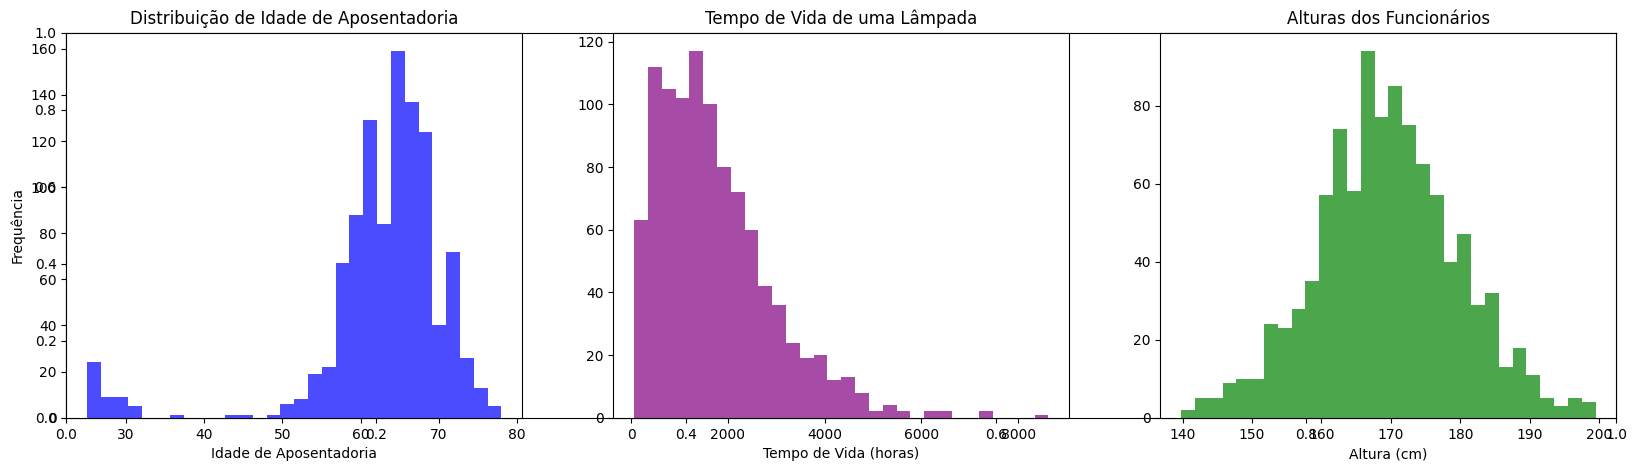

In [3]:
# Várias distribuições
plt.subplots(figsize=(20, 5))
plt.subplot(131)
plt.title('Distribuição de Idade de Aposentadoria')
plt.xlabel('Idade de Aposentadoria')
plt.ylabel('Frequência')
plt.hist(dados_idade_aposentadoria, bins=30, alpha=0.7, color='blue')

plt.subplot(132)
plt.hist(dados_vida_lampada, bins=30, alpha=0.7, color='purple')
plt.title('Tempo de Vida de uma Lâmpada')
plt.xlabel('Tempo de Vida (horas)')

plt.subplot(133)
plt.hist(dados_alturas, bins=30, alpha=0.7, color='green')
plt.title('Alturas dos Funcionários')
plt.xlabel('Altura (cm)')

plt.show()

In [4]:
from os import replace
# Reamostragens

# tamanho da amostra
n = 100

# quantidade de amostras
qnt = 100000

# função de reamostragem e cálculo de médias
def reamostragem_medias(dados, coluna, n, qnt):
    medias = [dados[coluna].sample(n, replace = True).mean()for i in range(qnt)]
    return medias

In [5]:
# Realizando as reamostragens com a função
medias_idade = reamostragem_medias(dados_idade_aposentadoria, 'idade', n, qnt)
medias_duracao = reamostragem_medias(dados_vida_lampada, 'duracao', n, qnt)
medias_altura = reamostragem_medias(dados_alturas, 'alturas', n, qnt)

In [6]:
print("*****  Médias populacionais *****")

print("idade:", dados_idade_aposentadoria['idade'].mean())
print("duracao:", dados_vida_lampada['duracao'].mean())
print("alturas:", dados_alturas['alturas'].mean())

*****  Médias populacionais *****
idade: 62.70857142857143
duracao: 1731.8036029420002
alturas: 169.52022


In [7]:
def Average(lst):
    return sum(lst) / len(lst)

print("*****  Médias amostrais *****")

print("idade:", Average(medias_idade))
print("duração:", Average(medias_duracao))
print("altura:", Average(medias_altura))


*****  Médias amostrais *****
idade: 62.70967970000061
duração: 1731.769806730301
altura: 169.5206398380003


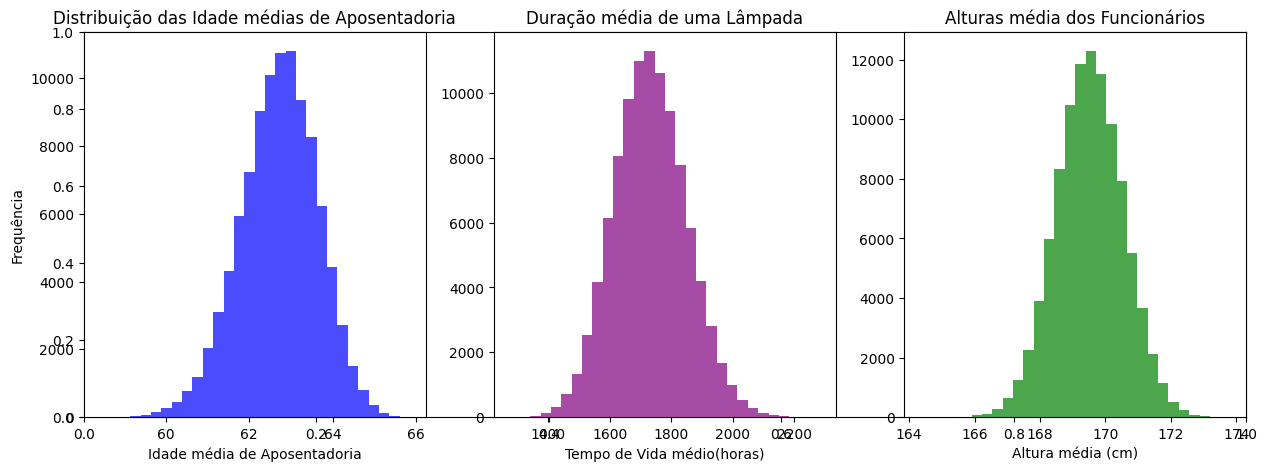

In [8]:
plt.subplots(figsize=(15, 5))
plt.subplot(131)
plt.title('Distribuição das Idade médias de Aposentadoria')
plt.xlabel('Idade média de Aposentadoria')
plt.ylabel('Frequência')
plt.hist(medias_idade, bins=30, alpha=0.7, color='blue')

plt.subplot(132)
plt.hist(medias_duracao, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio(horas)')

plt.subplot(133)
plt.hist(medias_altura, bins=30, alpha=0.7, color='green')
plt.title('Alturas média dos Funcionários')
plt.xlabel('Altura média (cm)')

plt.show()

In [9]:
# média da nova amostra
media_nova_amostra = 1200

In [10]:
# media original
media_populacional = dados_vida_lampada['duracao'].mean()

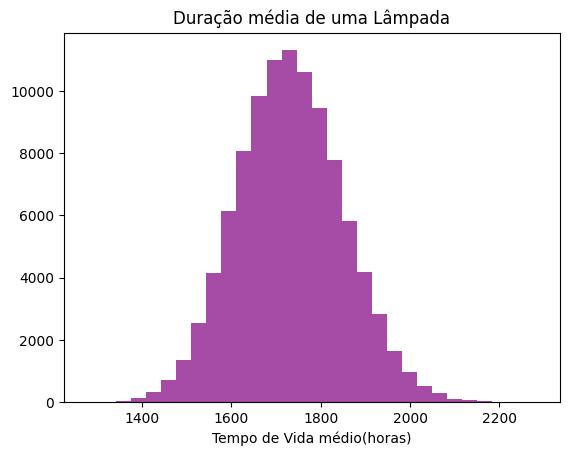

In [11]:
# Quão distante essa média está do comportamento?

plt.hist(medias_duracao, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio(horas)')
plt.annotate('.', xy=(media_nova_amostra, 0), xytext=(media_nova_amostra, 100), fontsize=8,
            arrowprops=dict(facecolor='green'))
plt.show()

In [12]:
# transformando medias_duração em DataFrame
duracao_amostras = pd.DataFrame({'medias_duracao': medias_duracao})

In [13]:
# calculando informações
media_das_medias = duracao_amostras['medias_duracao'].mean()
EP = duracao_amostras['medias_duracao'].std()

print("*****  Medidas amostrais *****")
print("média:", media_das_medias)
print("Erro Padrão:", EP )

*****  Medidas amostrais *****
média: 1731.7698067303459
Erro Padrão: 118.27983201249053


In [14]:
# Quantos erros?
1732 - EP

1732 - 3*EP

# EP vai ser o nosso parâmetrp do quão longe estamos

1377.1605039625283

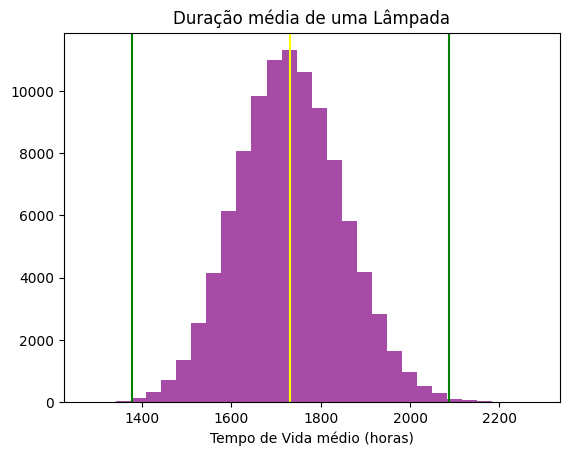

In [15]:
# Visualizando a quantidade de amostras entre 3EP +- da média.

plt.hist(medias_duracao, bins=30, alpha=0.7, color='purple')
plt.title('Duração média de uma Lâmpada')
plt.xlabel('Tempo de Vida médio (horas)')
plt.axvline(media_das_medias, color = "yellow")
plt.axvline(media_das_medias + 3*EP , color = "green")
plt.axvline(media_das_medias - 3*EP , color = "green")
plt.annotate('.', xy=(media_nova_amostra, 0), xytext=(media_nova_amostra, 100), fontsize=8,
            arrowprops=dict(facecolor='green'))
plt.show()

In [16]:
#quanto está no intervalo de +ou- dois desvio
qnt_obs = duracao_amostras[(duracao_amostras > media_das_medias - 3*EP) &
                          (duracao_amostras < media_das_medias + 3*EP)]


In [17]:
# quanto isso representa?
qnt_obs.count()/duracao_amostras.count()*100

,0
medias_duracao,99.72


In [18]:
# importando o stats
from scipy import stats

In [19]:
# levar em consideração essa amostra
dados_vida_lampada

# nível de confiança definido
confianca = 0.95

In [20]:
#informações para o IC
media = dados_vida_lampada['duracao'].mean()
desvio_padrao_amostral = dados_vida_lampada['duracao'].std()
tamanho_amostra = len(dados_vida_lampada)

In [21]:
# Calculando intervalo de confiança

intervalo_confianca = stats.norm.interval(confianca,
                                       loc=media , # parâmetro onde vamosa add a margem de erro
                                       scale=desvio_padrao_amostral/np.sqrt(tamanho_amostra)) # variabilidade = erro padrão

In [22]:
# Visualizando os resultados

print("IC (95%):", intervalo_confianca)

IC (95%): (np.float64(1658.3741665835485), np.float64(1805.233039300452))


In [23]:
import pandas as pd

# Conjunto de dados TechTaste
df_techtaste = pd.DataFrame({'avaliacoes': [38, 44, 33, 42, 47, 33, 36, 39, 42, 36, 39, 34, 42, 42, 36, 43, 31, 35, 36, 41, 42, 30, 25, 38, 47, 36, 32, 45, 44, 45, 37, 48, 37, 36, 44, 49, 31, 45, 45, 40, 36, 50, 38, 34, 36, 42, 46, 49, 36, 34, 38, 31, 53, 40, 57, 40, 36, 42, 26, 50, 32, 43, 35, 37, 42, 30, 36, 43, 40, 43, 44, 52, 37, 51, 35, 47, 40, 50, 37, 49]})

In [24]:
# desvio padrão amostral
dp_amostral = df_techtaste['avaliacoes'].std()

# erro padrão amostral
erro_padrao_amostral = stats.sem(df_techtaste['avaliacoes'])

print("Desvio padrão amostral:", dp_amostral)
print("Erro padrão amostral:", erro_padrao_amostral)

Desvio padrão amostral: 6.421827887581661
Erro padrão amostral: 0.7179821848218233


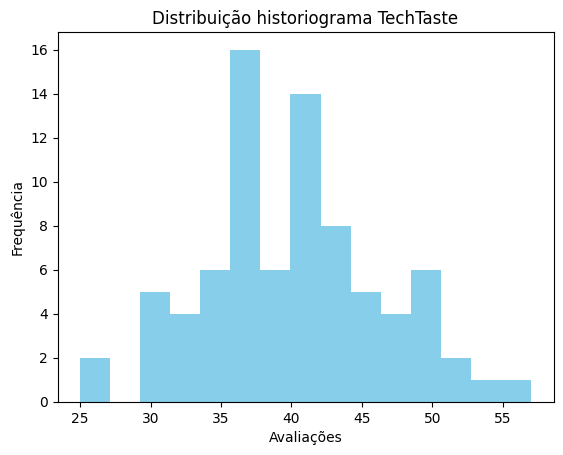

In [25]:
# gráfico histograma
import matplotlib.pyplot as plt

plt.hist(df_techtaste['avaliacoes'], bins=15, color='skyblue')
plt.title('Distribuição historiograma TechTaste')
plt.xlabel('Avaliações')
plt.ylabel('Frequência')
plt.show()

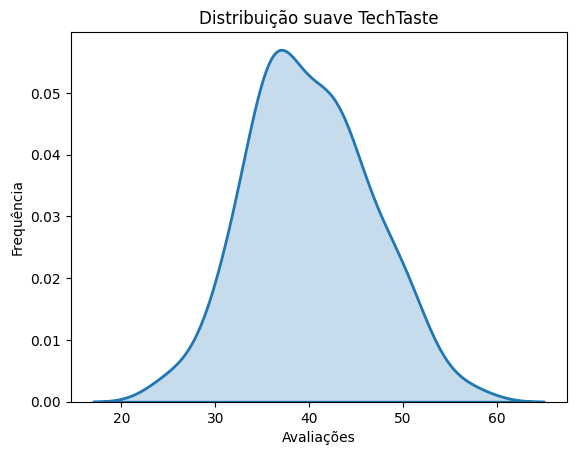

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(df_techtaste['avaliacoes'], linewidth=2, fill= True)

plt.xlabel('Avaliações')
plt.ylabel('Frequência')
plt.title('Distribuição suave TechTaste')
plt.show()

In [27]:
# intervalo de confiança a 90%
confianca = 0.9

# informações para o IC
media = df_techtaste['avaliacoes'].mean()

# Calculando intervalo de confiança

intervalo_confianca = stats.norm.interval(confianca,
                                       loc=media , # parâmetro onde vamosa add a margem de erro
                                       scale=erro_padrao_amostral) # variabilidade = erro padrão

print("IC (90%):", intervalo_confianca)

IC (90%): (np.float64(38.84402439920928), np.float64(41.205975600790715))


In [28]:

# e se fosse 95%?
confianca = 0.95

# Calculando intervalo de confiança

intervalo_confianca = stats.norm.interval(confianca,
                                       loc=media , # parâmetro onde vamosa add a margem de erro
                                       scale=desvio_padrao_amostral/np.sqrt(tamanho_amostra)) # variabilidade = erro padrão

print("IC (95%):", intervalo_confianca)

IC (95%): (np.float64(-33.40443635845167), np.float64(113.45443635845166))


In [29]:
# formulando hipótese nula: "A duração média de todas as lâmpadas é igual a 1.570 horas"
# H₀: µ = 1570
hipotese = 1570


# hipótese alternativa: "A duração média de todas as lâmpadas não é igual a 1.570 horas".
# H₁: µ ≠ 1570

In [30]:
# dados amostrais

lampadas_natalinas = pd.read_csv("https://raw.githubusercontent.com/isadorapandas/data-science-teste-hipoteses/refs/heads/main/experimento_lampadas_natalinas.csv")
lampadas_natalinas = pd.read_csv("/content/experimento_lampadas_natalinas.csv")

In [31]:
lampadas_natalinas['duracao'].mean()

np.float64(1529.5081310675512)

In [32]:
# informações para a região crítica

confianca = 0.95  # Nível de confiança desejado
desvio_padrao_populacional = 105  # dv/sigma dado pela fabrica
tamanho_amostra = len(lampadas_natalinas['duracao'])

In [33]:
# Calculando o IC

intervalo = stats.norm.interval( confianca,
                                 loc = 1570, # hipotese nula
                                 scale = desvio_padrao_populacional/np.sqrt(tamanho_amostra) )

In [34]:
print("IC (95%)): ", intervalo)

IC (95%)):  (np.float64(1549.4203781623294), np.float64(1590.5796218376706))


In [35]:
# como a nossa media foi de 1529.5081310675512 e está fora do IC,
# REJEITAMOS a hipótese nula de 1570

In [36]:
# Suponhamos que estamos no cenário errado, o cenário em que H₀ é verdadeira,
# ou seja, as lâmpadas estão durando 1.570 horas, em média.
# Qual a probabilidade de observarmos aquela média amostral que calculamos?
# Será que ela é menor ou maior do que o nível de significância,
# que é o erro que estamos admitindo, que é 5%?

In [37]:
# importando o teste Z do statsmodels
from statsmodels.stats.weightstats import ztest

# executando o teste z
stats, p_valor = ztest(x1 = lampadas_natalinas['duracao'],
                       value = 1570, # hipotese nula
                       alternative = "two-sided") # pois a hipotese alternativa é !=

In [38]:
print(p_valor)
print(stats)

0.0
-45.732770207263556


In [39]:
# verifica a hipótese nula com base no valor-p

if p_valor < 0.05:
    conclusao = "Rejeitar a hipótese nula"
else:
    conclusao = "Não rejeita a hipótese nula"

print("Conclusão:", conclusao)

Conclusão: Rejeitar a hipótese nula


In [40]:
import pandas as pd
from scipy import stats

# Conjunto de dados TechTaste
df_techtaste = pd.DataFrame({'avaliacoes': [38, 44, 33, 42, 47, 33, 36, 39, 42, 36, 39, 34, 42, 42, 36, 43, 31, 35, 36, 41, 42, 30, 25, 38, 47, 36, 32, 45, 44, 45, 37, 48, 37, 36, 44, 49, 31, 45, 45, 40, 36, 50, 38, 34, 36, 42, 46, 49, 36, 34, 38, 31, 53, 40, 57, 40, 36, 42, 26, 50, 32, 43, 35, 37, 42, 30, 36, 43, 40, 43, 44, 52, 37, 51, 35, 47, 40, 50, 37, 49]})
media = 30

In [41]:
# media amostral
media_amostral = df_techtaste['avaliacoes'].mean()
print(f'Média Amostral: {media_amostral}')

# hipoteses: H0: u = 30; H1: u != 30
hipotese = 30

# confiança
confianca = 0.95

#desvio padrao populacional
desvio_padrao_populacional = 2.65

# desvio padrão amostral
desvio_padrao_amostral = df_techtaste['avaliacoes'].std()

# tamanho da amostra
tamanho_amostra = len(df_techtaste['avaliacoes'])

Média Amostral: 40.025


In [42]:
# definindo o IC

intervalo = stats.norm.interval( confianca,
                                 loc = 30, # hipotese nula
                                 scale = desvio_padrao_populacional/np.sqrt(tamanho_amostra) )

In [43]:
print("IC (95%)): ", intervalo)

IC (95%)):  (np.float64(29.419303816868016), np.float64(30.580696183131984))


In [44]:
# a media está fora do intervalo, então rejeitamos h0

In [45]:
from statsmodels.stats.weightstats import ztest

stat, p_valor = ztest(x1=df_techtaste['avaliacoes'], value=hipotese, alternative='two-sided')

print(f'Estatística Z: {stat}')
print(f'Valor-p: {p_valor}')

Estatística Z: 13.96274198988354
Valor-p: 2.6311293593122384e-44


In [46]:
# o nível de significância do problema é 0.05, pois nosso nível de confiança é 95%
# p-valor é 2.63e-44 < 0.05, por isso rejeitamos a hipótese nula.

In [47]:
if p_valor < 0.05:
    conclusao = 'Rejeitar a hipótese nula'
else:
    conclusao = 'Não rejeita a hipótese nula'

print('Conclusão:', conclusao)

Conclusão: Rejeitar a hipótese nula


In [48]:
# Tempo de resposta em minutos para 25 solicitações de suporte
tempo_resposta = [28, 32, 29, 31, 30, 33, 28, 30, 31, 29,
                  30, 32, 29, 31, 30, 33, 28, 30, 31, 29,
                  30, 32, 24, 29, 30]

In [49]:
# Definindo hipóteses nulas e alternativas:
# H₀: μ = 30
# H₁: μ < 30, teste unilateral a esquerda
hipotese = 30

In [50]:
# Média coletada do tempo
np.mean(tempo_resposta)

np.float64(29.96)

In [51]:
# Importando ttest_1samp
from scipy.stats import ttest_1samp

In [52]:
# Realiza o teste t unilateral para uma amostra
# mais apropriado para essa situação, pois:
# não conhecemos informações sobre a população
# e a amostra é pequena
stats, p_valor = ttest_1samp(tempo_resposta, hipotese, alternative = "less")

In [53]:
print(p_valor)

0.4585970095667924


In [54]:
# Com base nesse resultado de um p_valor alto, não podemos afirmar que 29.96
# é significativamente menor que 30 para todos os atendimentos

In [55]:
nivel_significancia = 0.05

if p_valor < nivel_significancia:
    conclusao = "Rejeitar a hipótese nula"
else:
    conclusao = "Não rejeita a hipótese nula"

conclusao

'Não rejeita a hipótese nula'

In [56]:
# No final, informamos à empresa que não há evidências estatísticas para
# afirmar que o tempo médio do suporte é menor que 30 minutos,
# e encerramos nosso trabalho com a empresa de software entregando essas análises

In [57]:
import pandas as pd

# Conjunto de dados Techsafe
df_techsafe = pd.DataFrame({'porcentagem_compressao': [21.99342831, 20.7234714 , 22.29537708, 24.04605971, 20.53169325, 20.53172609, 24.15842563, 22.53486946, 20.06105123, 22.08512009, 20.07316461, 20.06854049, 21.48392454, 17.17343951, 17.55016433, 19.87542494, 18.97433776, 21.62849467, 19.18395185, 18.1753926, 23.93129754, 20.5484474 , 21.13505641, 18.15050363, 19.91123455]})

In [58]:
# hipotese nula: H = 20
hipotese = 20
# hipotese alternativa: H > 20

In [59]:
tamanho_amostra = len(df_techsafe['porcentagem_compressao'])
media_amostral = df_techsafe['porcentagem_compressao'].mean()
desvio_padrao_amostral = df_techsafe['porcentagem_compressao'].std()

print(f'Tamanho da amostra: {tamanho_amostra}')
print(f'Média amostral: {media_amostral}')
print(f'Desvio padrão amostral: {desvio_padrao_amostral}')

Tamanho da amostra: 25
Média amostral: 20.6729838832
Desvio padrão amostral: 1.9131061090692592


In [60]:
# confiança
confianca = 0.95
significancia = 1 - confianca

print(f'Confiança: {confianca}')
print(f'Significância: {significancia}')

Confiança: 0.95
Significância: 0.050000000000000044


In [61]:
from scipy.stats import ttest_1samp

stat, p_valor = ttest_1samp(df_techsafe['porcentagem_compressao'], hipotese, alternative = "greater")

print(f'Estatística T: {stat}')
print(f'Valor-p: {p_valor}')

Estatística T: 1.7588775656761988
Valor-p: 0.04567200091129674


In [62]:
if p_valor < significancia:
    conclusao = 'Rejeitar a hipótese nula'
else:
    conclusao = 'Não rejeita a hipótese nula'

print('Conclusão:', conclusao)

Conclusão: Rejeitar a hipótese nula


In [63]:
# vendas vs anuncios
vendas_com_propaganda = [329.80, 291.70, 338.86, 391.38,
                         285.95, 285.95, 394.75, 346.05,
                         271.83, 332.55, 272.19, 272.06,
                         314.52, 185.20, 196.50, 266.26,
                         239.23, 318.85, 245.52, 215.26,
                         387.94, 286.45, 304.05, 214.52,
                         267.34, 306.66, 230.94, 322.54,
                         263.96, 282.50, 263.90, 411.14,
                         299.19, 236.54, 349.35, 226.75,
                         312.53, 182.42, 220.31, 311.81,
                         344.31, 310.28, 293.06, 281.93,
                         211.29, 256.81, 272.36, 363.43,
                         320.62, 194.22]
vendas_sem_propaganda = [304.44, 261.89, 244.38, 321.70,
                         346.86, 340.88, 234.65, 266.45,
                         304.88, 343.53, 256.25, 273.86,
                         218.62, 213.23, 333.75, 366.37,
                         280.68, 345.21, 306.70, 246.29,
                         306.68, 377.28, 282.85, 378.88,
                         127.82, 334.31, 290.22, 267.06,
                         290.51, 165.74, 271.82, 306.43,
                         373.67, 253.90, 236.49, 254.89,
                         339.92, 304.73, 253.21, 315.80,
                         290.82, 343.12, 242.88, 265.34,
                         261.47, 197.19, 302.77, 300.66,
                         285.31, 270.92]

In [64]:
media_vendas_com_propaganda = np.mean(vendas_com_propaganda)
media_vendas_sem_propaganda = np.mean(vendas_sem_propaganda)

print(f'Média de vendas com propaganda: {media_vendas_com_propaganda}')
print(f'Média de vendas sem propaganda: {media_vendas_sem_propaganda}')

Média de vendas com propaganda: 286.4712
Média de vendas sem propaganda: 286.0662


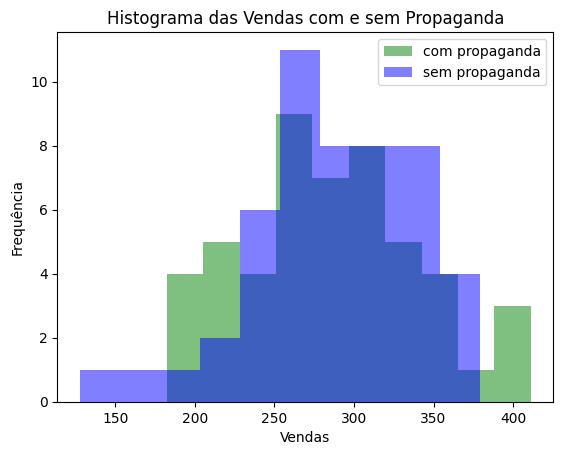

In [65]:
# criando um histograma
plt.hist(vendas_com_propaganda, color = "green", alpha = 0.5, label = "com propaganda")
plt.hist(vendas_sem_propaganda, color = "blue", alpha = 0.5, label = "sem propaganda")

# Adicionar rótulos e título
plt.xlabel('Vendas')
plt.ylabel('Frequência')
plt.title('Histograma das Vendas com e sem Propaganda')
plt.legend()
plt.show()

In [66]:
# há uma diferença substancial nesse comportamento?
# É realmente o caso de que quem foi exposto aos anúncios no e-commerce gastou mais?
# Para determinar se há uma diferença significativa entre esses dois grupos,
# é necessário conduzir um teste de independência

In [67]:
from scipy.stats import ttest_ind

# hipoteses desse teste de amostras independentes:
# H0: média sem = média com, ou seja, as propagandas não tiveram efeito
# H1: média sem < média com

stats, p_valor = ttest_ind (vendas_com_propaganda, vendas_sem_propaganda,
           alternative = "greater")

In [68]:
print(f'Estatística T: {stats}')
print(f'Valor-p: {p_valor}')

Estatística T: 0.03731421838932492
Valor-p: 0.48515518670338376


In [69]:
# p_valor é muito alto
# A probabilidade é muito alta no cenário de H₀, ou seja, não temos evidências
# de rejeitar o que está escrito em H₀ (que, na verdade, não tem efeito nenhum)
# A média de quem compra com propaganda não tem muita diferença de quem compra sem propaganda.

In [70]:
confianca = 0.95
significancia = 1 - confianca

if p_valor < significancia:
    conclusao = 'Rejeitar a hipótese nula: Há evidências de que a propaganda tem um efeito positivo nas vendas.'
else:
    conclusao = 'Não rejeita a hipótese nula: Não rejeita hipótese nula: Não há evidências suficientes para afirmar um efeito positivo nas vendas devido à propaganda.'

print('Conclusão: ', conclusao)

Conclusão:  Não rejeita a hipótese nula: Não rejeita hipótese nula: Não há evidências suficientes para afirmar um efeito positivo nas vendas devido à propaganda.


In [71]:
# notas antes e depois
# Precisamos testar se o treinamento
# para a equipe de atendimento promoveu uma diferença nas avaliações

In [72]:
antes_do_treinamento =[78, 65, 75, 80, 85, 88, 79, 81, 76, 84]
apos_o_treinamento = [85, 70, 75, 87, 90, 92, 84, 82, 76, 91]

In [73]:
# Comparando antes e depois
resultado_subtracao = [b - a for a, b in zip(antes_do_treinamento,apos_o_treinamento)]
resultado_subtracao

[7, 5, 0, 7, 5, 4, 5, 1, 0, 7]

In [74]:
# precisamos aplicar um teste de amostras dependentes, pois são as mesmas pessoas
# que estamos comparando. essas são amostras pareadas, pois há sempre um par para comparar

In [75]:
from scipy.stats import ttest_rel

# hipóteses desse teste de amostras pareadas:
# H0 : µd = 0, ou seja, o treinamento não teve efeito
# H1 : µd > 0
# µd é média das diferenças dos pares

hipotese = 0

In [76]:
stats, p_valor = ttest_rel(apos_o_treinamento, antes_do_treinamento,
                           alternative="greater")

print(f'Estatística T: {stats}')
print(f'Valor-p: {p_valor}')

Estatística T: 4.619361962060379
Valor-p: 0.000627744161772394


In [77]:
if p_valor < 0.05:
    conclusao = "Rejeita a hipótese nula"
else:
    conclusao = "Não rejeita a hipótese nula"

print("Conclusão:", conclusao)

Conclusão: Rejeita a hipótese nula


In [78]:
# O p_valor foi muito baixo, ou seja, rejeitamos a hipótese nula, que é que não houve diferença.
# Assumimos, então, que há uma diferença após o treinamento
# E essa diferença é maior na satisfação dos nossos clientes

In [79]:
# caso 1 Zoop Megastore
import pandas as pd

df_equipe_vendas = pd.DataFrame({'Vendedor': [ 'Luíza', 'Bia', 'Rodrigo', 'Allan', 'Evaldo'],
                                 'Vendas Antes (R$)': [252.72, 203.91, 307.32, 185.78, 220.5],
                                 'Vendas Depois (R$)': [285.1, 223.15, 324.41, 202.23, 240.63]})

In [81]:
# a amostra é pareada
# hipoteses:
# H0: ud = 0
# H1: ud != 0
hipotese = 0

In [87]:
from scipy.stats import ttest_rel

stats, p_valor = ttest_rel(df_equipe_vendas['Vendas Depois (R$)'],
                           df_equipe_vendas['Vendas Antes (R$)'])

print(f'Estatística T pareado: {stats}')
print(f'Valor-p: {p_valor}')

Estatística T pareado: 7.23705258430516
Valor-p: 0.0019344230773580572


In [88]:
if p_valor < 0.05:
    conclusao = "Rejeita a hipótese nula"
else:
    conclusao = "Não rejeita a hipótese nula"

print("Conclusão:", conclusao)

Conclusão: Rejeita a hipótese nula


In [89]:
# como p_valor é baixo, rejeita-se a hipótese nula, o que significa que
# o treinamento fez efeito

In [90]:
# caso 2 Zoop Megastore
import pandas as pd

df_filiais = pd.DataFrame({'Filial Centro-Norte': [3.2, 2.9, 2.0, 3.3, 3.1],
                           'Filial Sul': [3.8, 4.0, 4.7, 4.9, 4.8]})

In [91]:
# a amostra é independente
# hipoteses:
# H0: ucn = us
# H1: ucn != us

In [92]:
from scipy.stats import ttest_ind

stats, p_valor = ttest_ind(df_filiais['Filial Centro-Norte'],
                           df_filiais['Filial Sul'])

print(f'Estatística T independente: {stats}')
print(f'Valor-p: {p_valor}')

Estatística T independente: -4.73902240270431
Valor-p: 0.001465798816319686


In [93]:
if p_valor < 0.05:
    conclusao = "Rejeita a hipótese nula"
else:
    conclusao = "Não rejeita a hipótese nula"

print("Conclusão:", conclusao)

Conclusão: Rejeita a hipótese nula
